In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Wedge

from datetime import datetime
from calendar import monthrange
from HARey.astro_functions import equation_of_time
import os
import numpy as np

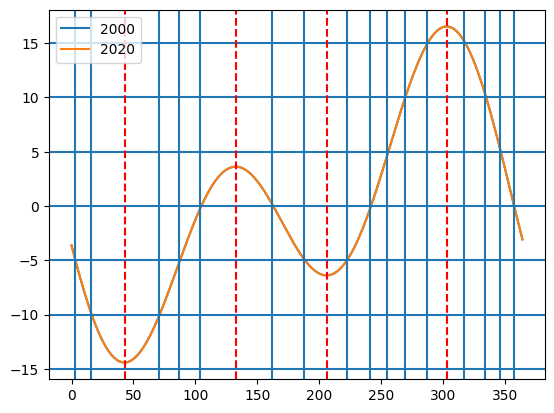

{-15: array([], dtype=int64), -10: array([16, 71]), -5: array([  3,  87, 188, 222]), 0: array([104, 162, 241, 357]), 5: array([255, 346]), 10: array([269, 334]), 15: array([287, 317]), -14: [np.int64(43)], 4: [np.int64(133)], -6: [np.int64(206)], 17: [np.int64(303)]}


In [3]:
plt.plot(range(365), equation_of_time(2000, np.arange(1,366)), label='2000')
plt.plot(range(365), equation_of_time(2001, np.arange(1,366)), label='2020')


eot = equation_of_time(2000, np.arange(1,366))


roots_dict = {}

for i in range(-15, 20, 5):

    l = i
    roots = np.argwhere((eot[:-1] - l)*(eot[1:] - l) < 0).flatten()
    [plt.axvline(x = root) for root in roots]
    plt.axhline(l)
    roots_dict[i] = roots

# add mins and maxs
diffs = np.diff(eot)
min_max = np.argwhere(diffs[:-1]*diffs[1:] < 0).flatten()
min_max = min_max + 1
roots_dict.update({int(key): [val] for key, val in zip(np.round(eot[min_max]),  min_max)})
[plt.axvline(x = mm, color='r', ls='--') for mm in min_max]

plt.legend()
plt.show()

print(roots_dict)

In [4]:

def draw_moon(ax, day, center_xy = (0,0), radius = 1.0, lw=0.1):
    
    (center_x, center_y) = center_xy

    month_length=29.53

    # Phase angle (Sun-Moon-Observer) from 0 (new) to to pi (full) and back
    phase_angle = 2*np.pi * (day / month_length)

    # Circle for the lunar disk
    t = np.linspace(0, 2*np.pi, 100)
    moon_x, moon_y = center_x + radius*np.cos(t), center_y + radius*np.sin(t)

    # Plot a black moon
    ax.fill(moon_x, moon_y, color="black", lw=lw)  
    ax.plot(moon_x, moon_y, color="black", lw=lw)   

    sign = 1 if phase_angle <= np.pi else -1

    # Terminator ellipse (projected shadow line)
    tt = np.linspace(-np.pi/2, np.pi/2, 50)
    x, y = center_x + radius * sign * np.cos(phase_angle) * np.cos(tt), center_y + radius * np.sin(tt)
    limb_x, limb_y = center_x + radius * sign *np.cos(tt), center_y + radius * np.sin(tt)

    # Build illuminated polygon: ellipse arc + limb arc
    # The shape is filled correctly if the points are given in counter-clockwise order
    if phase_angle <= np.pi:  # waxing (right side lit)
        poly_x = np.concatenate([x, limb_x[::-1]])
        poly_y = np.concatenate([y, limb_y[::-1]])
    else:  # waning (left side lit)

        poly_x = np.concatenate([limb_x, x[::-1]])
        poly_y = np.concatenate([limb_y, y[::-1]])

    ax.fill(poly_x, poly_y, color="white", lw=0)   # illuminated part

In [5]:
def circle_index(ax, r_in, r_out, r_cut=0.0, cut_size=0.0, index_angle=np.pi/12, lw=1.2, color='k'):

    if not isinstance(r_cut, (list, tuple)):
        r_cut = [r_cut]

    if not isinstance(cut_size, (list, tuple)):
        cut_size = [cut_size]

    t = np.linspace(0, 2*np.pi-index_angle, 100)
    circle_x, circle_y = r_in*np.sin(t), r_in*np.cos(t)
    
    t = np.linspace(2*np.pi - 0.5*index_angle*r_in/r_out, 2*np.pi, 10)

    l = index_angle*r_in/r_out*np.pi

    r = np.linspace(r_out - l, r_out, 10)
    index_x, index_y = r*np.sin(t), r*np.cos(t)

    plot_x, plot_y = np.concat([circle_x, index_x]), np.concat([circle_y, index_y])

    for (r, size) in zip(r_cut, cut_size):
        t_cut = np.linspace(0, np.pi, 50)
        cut_x, cut_y = -0.5*size*np.sin(t_cut), r + 0.5*size*np.cos(t_cut)

        plot_x, plot_y = np.concat([plot_x, cut_x]), np.concat([plot_y, cut_y])

    plot_x, plot_y = np.concat([plot_x, [0]]), np.concat([plot_y, [r_in]])   

    ax.plot(plot_x, plot_y, lw=lw, color=color)


In [6]:
from HARey.astro_functions import ecliptic2radec
from HARey.curved_text import curved_text

def plot_volvella(save_folder, figsize = 8, long = 0, GMT=0, ratio = 5):

    #Check if the directory already exists, if not make it
    if not os.path.exists(save_folder):
        os.mkdir(save_folder)

    # create five figures (one for each dial, the first for preview)
    fig, ax = [], []

    for i in range(5):
        fig_i, ax_i = plt.subplots(figsize=(figsize, figsize), dpi=300)
        fig_i.subplots_adjust()
        fig.append(fig_i)   
        ax.append(ax_i)

        ax[i].set_xlim(-1.01*figsize, 1.01*figsize)
        ax[i].set_ylim(-1.01*figsize, 1.01*figsize)
        ax[i].set_aspect('equal')
        ax[i].set_axis_off()

    # Radius of the different sections
    r_border = figsize
    r_compass = 0.98*figsize
    r_datetime = 0.85*figsize
    r_days = 0.70*figsize
    r_RA = 0.65*figsize
    r_zodiac = 0.60*figsize
    r_sun = 0.50*figsize
    r_moon = 0.30*figsize

    # Plot border circle (for all figures)
    [ax[i].add_patch(Circle((0,0), r_border, facecolor='none', edgecolor='k')) for i in range(5)]

    #####################################################################################################################################################################################

    # Draw wedges in the compass
    n_wedges = 48
    for w in range(0, n_wedges, 2):
        [ax[i].add_patch(Wedge(center=(0,0), r= r_border, theta1=w*360/n_wedges, theta2=(w+1)*360/n_wedges, width= r_border-r_compass, facecolor='k', edgecolor='none')) for i in (0,1)]

    # Draw compass circle
    [ax[i].add_patch(Circle((0,0), r_compass, facecolor='none', edgecolor='k')) for i in (0,1)]

    # Plot dirctions labels
    directions = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
    r_directions = r_datetime + (r_compass - r_datetime)*0.75

    for d in range(16):
        a = np.pi/8 * d
        [curved_text(ax[i], directions[d], r_directions, angle_offset=a, font_size=figsize*0.03) for i in (0,1)]

    # Draw daytime circle
    [ax[i].add_patch(Circle((0,0), r_datetime, facecolor='none', edgecolor='k')) for i in (0,1)]

    # If the long is not zero, compute the local time offset (in hours)
    
    delta_t_long = long/15 - GMT

    # Plot hours
    r_hours = r_datetime + (r_compass-r_datetime)*0.45

    # Plot hours labels
    for h in range(1, 25):
        a = np.pi/12 * (h + delta_t_long)        
        # plot Hours (0-24)
        [curved_text(ax[i], f'{h:02}', r_hours, angle_offset=a, font_size=figsize*0.03) for i in (0,1)]

    # Plot hours ticks
    for r, ticks in zip([0.25, 0.20, 0.15, 0.075], [1, 2, 4, 12]):
        r_index = r_datetime + (r_compass-r_datetime)*r
        for angle in np.linspace(np.pi/12*delta_t_long, 2*np.pi + np.pi/12*delta_t_long, 24*ticks + 1):  # Plot half-hours
            [ax[i].plot((r_datetime*np.sin(angle), r_index*np.sin(angle)), (r_datetime*np.cos(angle), r_index*np.cos(angle)), color='k', lw=0.6) for i in (0,1)]
    
    ##############################################################################################################################################################################

    # Plot datetime circle
    [ax[i].add_patch(Circle((0,0), r_datetime, facecolor='none', edgecolor='k')) for i in (0,2)]

    r_months = r_days + (r_datetime-r_days)*0.60
    r_day_label = r_days + (r_datetime-r_days)*0.30

    # Angle of the spring Equinox, which correspond to the 0 RA value, which will be up
    equinox_offest = datetime(2001,3,20).timetuple().tm_yday/365

    # Plot dates and months
    for m in range(1,13):
        days_in_month = monthrange(2001,m)[1]

        # Plot the day label
        for day in range(1,days_in_month+1,1):
            # Get the angle as a fraction of the whole year
            a = -2*np.pi*(datetime(2001, m, day).timetuple().tm_yday/365 - equinox_offest)
            # Plot different markers if the day is divisible by 5 and add the number
            if day%5==0:
                [curved_text(ax[i], f'{day}', r_day_label, angle_offset=a, font_size=figsize*0.025) for i in (0,2)]
                [ax[i].plot((r_days*np.sin(a)), (r_days*np.cos(a)), marker = 'o', markersize=1.5, mfc='none', mec='k', mew=0.4) for i in (0,2)]            
            else:
                [ax[i].plot((r_days*np.sin(a)), (r_days*np.cos(a)), marker = 'o', markersize=1.5, mfc='k', mec='k', mew=0.4) for i in (0,2)]

        # Plot the month label
        angle = -2*np.pi*((datetime(2001, m, 1).timetuple().tm_yday + days_in_month/2)/365 - equinox_offest)
        month_name = f'{datetime(2001,m,1).strftime('%B').upper()}'
        [curved_text(ax[i], month_name, r_months, angle_offset=a, font_size=figsize*0.03) for i in (0,2)]

    r_eot = r_zodiac + (r_days-r_zodiac)*0.70
    r_RA = r_zodiac + (r_days-r_zodiac)*0.55

    # Plot equation of time 
    eot = equation_of_time(2000, np.arange(1,366))

    # Compute levels of the equation of time and its maximum and minimum
    roots_dict = {}
    for i in range(-15, 20, 5):

        l = i
        roots = np.argwhere((eot[:-1] - l)*(eot[1:] - l) < 0).flatten()
        [plt.axvline(x = root) for root in roots]
        plt.axhline(l)
        roots_dict[i] = roots

    # add mins and maxs
    diffs = np.diff(eot)
    min_max = np.argwhere(diffs[:-1]*diffs[1:] < 0).flatten()
    min_max = min_max + 1
    roots_dict.update({int(key): [val] for key, val in zip(np.round(eot[min_max]),  min_max)})
    [plt.axvline(x = mm, color='r', ls='--') for mm in min_max]


    for eot in roots_dict.keys():
        for date in roots_dict[eot]:
            angle = ((date + 0.5)/365 - equinox_offest)* 2* np.pi 
            [curved_text(ax[i], f'{eot:+d}', r_eot, angle_offset=-angle, font_size=figsize*0.02) for i in (0,2)]

    # Plot RA ring
    [ax[i].add_patch(Circle((0,0), r_zodiac, facecolor='none', edgecolor='k', linestyle='-', lw=0.8)) for i in (0,2)]

    # Plot RA labels
    for h in range(1, 25):
        a = -np.pi/12 * h
        [curved_text(ax[i], f'{h:02} h', r_zodiac + (r_RA-r_zodiac)*0.75, angle_offset=a, font_size=figsize*0.025) for i in (0,2)]
    # Plot RA ticks
    for r, ticks in zip([0.45, 0.35, 0.20], [1, 2, 4]):
        r_index = r_zodiac + (r_RA-r_zodiac)*r
        for angle in np.linspace(0, 2*np.pi, 24*ticks + 1):  # Plot half-hours
            [ax[i].plot((r_zodiac*np.sin(angle), r_index*np.sin(angle)), (r_zodiac*np.cos(angle), r_index*np.cos(angle)), color='k', lw=0.6) for i in (0,2)]

    # Plot zodiac ring
    [ax[i].add_patch(Circle((0,0), r_zodiac, facecolor='none', edgecolor='k', linestyle='-', lw=0.8)) for i in (0,2)]

    # Plot zodiac names and symbols
    zodiac_names = ['Aries', 'Taurus', 'Gemini', 'Cancer', 'Leo', 'Virgo', 'Libra', 'Scorpio', 'Sagittarius', 'Capricorn', 'Acquarius', 'Pisces']
    zodiac_symbols = ['\u2648', '\u2649', '\u264A', '\u264B', '\u264C', '\u264D','\u264E', '\u264F', '\u2650', '\u2651', '\u2652', '\u2653']

    r_zodiac_names = r_sun + (r_zodiac -r_sun)*0.5

    for s in range(12):
        # Plot zodiac signs borders
        angle, _ = ecliptic2radec(30*s ,0)
        angle = -np.deg2rad(angle)
        [ax[i].plot((r_sun*np.sin(angle), r_zodiac*np.sin(angle)), (r_sun*np.cos(angle), r_zodiac*np.cos(angle)), ls=':', color='k', lw=0.8) for i in (0,2)]
        # Plot zodiac signs names
        angle, _ = ecliptic2radec(30*s + 15 ,0)
        angle = np.deg2rad(angle)
        [curved_text(ax[i], f'{zodiac_names[s]} {zodiac_symbols[s]}', r=r_zodiac_names, angle_offset=angle, font_size=figsize*0.03) for i in (0,2)]

    ##################################################################################################################################################################

    # Plot sun dial
    [circle_index(ax[i], r_in = r_sun, r_out = r_hours, r_cut = r_day_label, cut_size=0.35, lw=1) for i in (0,3)]

    # Plot lunar month days
    sinodic_month = 29.53

    r_phases = r_moon + (r_sun - r_moon)*0.80

    for d in range(0,30):
        a = - 2*np.pi*d/sinodic_month
        [curved_text(ax[i], f'{d}', r_phases, angle_offset=a, font_size=figsize*0.025) for i in (0,3)]

    # Plot Lunar phases
    n_moons = 12
    r_moons = r_moon + (r_sun - r_moon)*0.35
    moon_size = (r_sun - r_moon)*0.2

    for m in range(n_moons):
        angle = -m *2*np.pi/n_moons
        [draw_moon(ax[i], day = m/n_moons*sinodic_month, center_xy=(r_moons*np.sin(angle), r_moons*np.cos(angle)), radius=moon_size, lw=0.2) for i in (0,3)]

    # Plot the cycloid
    r_cycloid = 0.9*r_moon
    ratio = 4   # ratio between the cyclid inner radius and the moon cutout size
    r_in = r_cycloid/(1 + 2/ratio)
    r_mask = (r_cycloid - r_in)*0.5

    # Draw the lunar cycloid
    [ax[i].add_patch(Circle((0,0), radius = r_cycloid, facecolor='k', edgecolor='none')) for i in (0,3)]
    theta = np.linspace(0, 2*np.pi, 101)
    r_cycloid = r_in - r_mask*(np.cos(theta) - 1)
    [ax[i].fill(r_cycloid*np.sin(theta), r_cycloid*np.cos(theta), color='w', lw=0) for i in (0,3)]


    '''
    for i in range(8):
        x, y = (r_in + r_mask)*np.sin(i*np.pi/4), (r_in + r_mask)*np.cos(i*np.pi/4)
        [ax[i].add_patch(Circle((x,y), r_mask, facecolor='none', edgecolor='orange'))
    '''

    ###############################################################################################################################################################


    # Plot the moon dial
    [circle_index(ax[i], r_moon, r_out=r_datetime, r_cut = [r_phases, r_moons], cut_size=(0.4, 2*moon_size), lw=1, color='k') for i in (0,4)]

    # Plot the cycloid cutout
    [ax[i].add_patch(Circle((0, r_in + r_mask), r_mask, facecolor='none', edgecolor='k')) for i in (0,4)]

    # Mark center in every plot
    [ax[i].plot(0,0, marker = 'x', color='k') for i in (1,2,3,4)]

    # Save and close all plots excet for the preview
    [fig[i].savefig(f'{save_folder}/volvella_{i}', dpi = 300, transparent=True, bbox_inches=None, pad_inches=0) for i in (1,2,3,4)]
    [plt.close(fig[i]) for i in (1,2,3,4)]

    # Plot the preview
    plt.show(fig[0])

In [ ]:
plot_volvella('m', long = 10, GMT=1)

In [ ]:
from HARey.astro_projection import ecliptic2radec

In [ ]:
ecliptic2radec(60,0)

(np.float64(57.82641197634796), np.float64(20.117112763269187))